Mean Squared Error (MSE): 4101.592276973193
R² Score: 0.2258446961015086


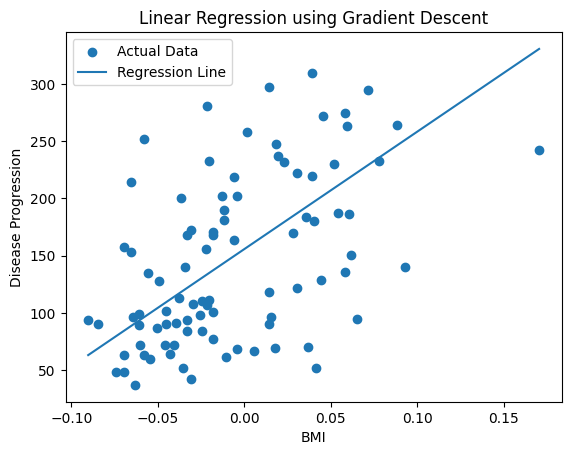

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load real-world dataset
data = load_diabetes()

# 2. Select one feature for visualization (BMI)
X = data.data[:, 2].reshape(-1, 1)   # BMI
y = data.target

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Linear Regression using Gradient Descent (SGD)
model = SGDRegressor(
    max_iter=2000,
    learning_rate='constant',
    eta0=0.01,
    random_state=42
)
model.fit(X_train_scaled, y_train)

# 6. Predictions
y_pred = model.predict(X_test_scaled)

# 7. Performance metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# 8. Sort values for plotting regression line
sorted_index = np.argsort(X_test.flatten())
X_sorted = X_test[sorted_index]
y_sorted_pred = y_pred[sorted_index]

# 9. Plot
plt.figure()
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_sorted, y_sorted_pred, label="Regression Line")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Linear Regression using Gradient Descent")
plt.legend()
plt.show()
